In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [8]:
import glob
import numpy as np
import os

npy_files = glob.glob("/kaggle/input/**/*.npy", recursive=True)

print("NPY files found:", len(npy_files))

for f in npy_files:
    arr = np.load(f, mmap_mode="r")

    print("\n", os.path.basename(f))
    print("Shape:", arr.shape)
    print("Dtype:", arr.dtype)

NPY files found: 5

 masks_medseg.npy
Shape: (100, 512, 512, 4)
Dtype: bool

 images_medseg.npy
Shape: (100, 512, 512, 1)
Dtype: float64

 test_images_medseg.npy
Shape: (10, 512, 512, 1)
Dtype: float64

 masks_radiopedia.npy
Shape: (829, 512, 512, 4)
Dtype: bool

 images_radiopedia.npy
Shape: (829, 512, 512, 1)
Dtype: float64


In [9]:
# ============================================================
# COVID CHEST CT — DATA PREPARATION
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/covid-segmentation"

X_med = np.load(BASE + "/images_medseg.npy")
Y_med = np.load(BASE + "/masks_medseg.npy")

X_radio = np.load(BASE + "/images_radiopedia.npy")
Y_radio = np.load(BASE + "/masks_radiopedia.npy")

X_test = np.load(BASE + "/test_images_medseg.npy")

print("MedSeg:", X_med.shape, Y_med.shape)
print("Radiopaedia:", X_radio.shape, Y_radio.shape)
print("Test:", X_test.shape)

# Combine labeled datasets
X = np.concatenate([X_med, X_radio], axis=0)
Y = np.concatenate([Y_med, Y_radio], axis=0)

print("\nCombined:")
print("X:", X.shape)
print("Y:", Y.shape)

# Convert masks to float
Y = Y.astype(np.float32)

# Check mask channel pixel counts
for i in range(Y.shape[-1]):
    print(
        f"Mask channel {i}:",
        int(Y[..., i].sum()),
        "positive pixels"
    )

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/covid-segmentation/images_medseg.npy'

In [10]:
import os
import glob
import numpy as np

# Find the actual files automatically
files = {}

for name in [
    "images_medseg.npy",
    "masks_medseg.npy",
    "test_images_medseg.npy",
    "images_radiopedia.npy",
    "masks_radiopedia.npy"
]:
    matches = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    if not matches:
        raise FileNotFoundError(f"Could not find {name}")
    
    files[name] = matches[0]
    print(name, "→", matches[0])

# Load using the actual paths
X_med = np.load(files["images_medseg.npy"])
Y_med = np.load(files["masks_medseg.npy"])

X_radio = np.load(files["images_radiopedia.npy"])
Y_radio = np.load(files["masks_radiopedia.npy"])

X_test = np.load(files["test_images_medseg.npy"])

print("\nLoaded successfully:")
print("MedSeg:", X_med.shape, Y_med.shape)
print("Radiopaedia:", X_radio.shape, Y_radio.shape)
print("Test:", X_test.shape)

images_medseg.npy → /kaggle/input/competitions/covid-segmentation/images_medseg.npy
masks_medseg.npy → /kaggle/input/competitions/covid-segmentation/masks_medseg.npy
test_images_medseg.npy → /kaggle/input/competitions/covid-segmentation/test_images_medseg.npy
images_radiopedia.npy → /kaggle/input/competitions/covid-segmentation/images_radiopedia.npy
masks_radiopedia.npy → /kaggle/input/competitions/covid-segmentation/masks_radiopedia.npy


KeyboardInterrupt: 

In [12]:
# ============================================================
# COMBINE + INSPECT COVID CT MASKS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Combine labeled data
X = np.concatenate([X_med, X_radio], axis=0)
Y = np.concatenate([Y_med, Y_radio], axis=0)

print("Combined X:", X.shape)
print("Combined Y:", Y.shape)
print("Image dtype:", X.dtype)
print("Mask dtype:", Y.dtype)

# Pixel count for each mask channel
print("\nMask channel pixel counts:")
for c in range(4):
    print(f"Channel {c}: {Y[..., c].sum():,.0f}")

# Check one sample
idx = 100

plt.figure(figsize=(15, 4))

plt.subplot(1, 5, 1)
plt.imshow(X[idx].squeeze(), cmap="gray")
plt.title("CT")
plt.axis("off")

for c in range(4):
    plt.subplot(1, 5, c + 2)
    plt.imshow(Y[idx, :, :, c], cmap="gray")
    plt.title(f"Mask Channel {c}")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'X_radio' is not defined

Files found:
X_med: /kaggle/input/competitions/covid-segmentation/images_medseg.npy
Y_med: /kaggle/input/competitions/covid-segmentation/masks_medseg.npy
X_radio: /kaggle/input/competitions/covid-segmentation/images_radiopedia.npy
Y_radio: /kaggle/input/competitions/covid-segmentation/masks_radiopedia.npy
X_test: /kaggle/input/competitions/covid-segmentation/test_images_medseg.npy

DATA LOADED
MedSeg X: (100, 512, 512, 1)
MedSeg Y: (100, 512, 512, 4)
Radio X : (829, 512, 512, 1)
Radio Y : (829, 512, 512, 4)
Combined X: (929, 512, 512, 1)
Combined Y: (929, 512, 512, 4)
Test X: (10, 512, 512, 1)

Mask channel pixel counts:
Channel 0: 3,415,470
Channel 1: 1,085,462
Channel 2: 36,745,236
Channel 3: 202,308,145


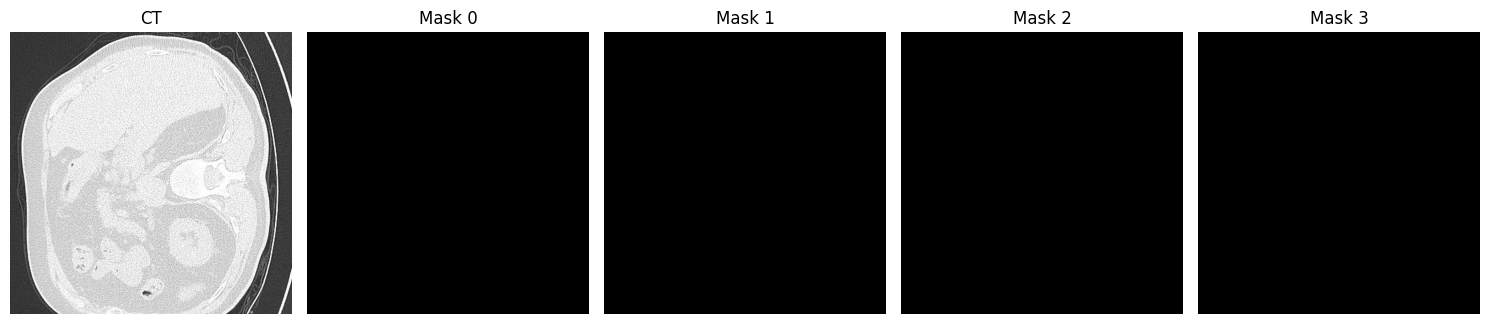

In [13]:
# ============================================================
# LOAD + COMBINE COVID CT DATA
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def find_file(filename):
    matches = glob.glob(
        f"/kaggle/input/**/{filename}",
        recursive=True
    )
    if not matches:
        raise FileNotFoundError(f"Cannot find {filename}")
    return matches[0]

# Find exact files
paths = {
    "X_med": find_file("images_medseg.npy"),
    "Y_med": find_file("masks_medseg.npy"),
    "X_radio": find_file("images_radiopedia.npy"),
    "Y_radio": find_file("masks_radiopedia.npy"),
    "X_test": find_file("test_images_medseg.npy")
}

print("Files found:")
for key, path in paths.items():
    print(f"{key}: {path}")

# Load
X_med = np.load(paths["X_med"])
Y_med = np.load(paths["Y_med"])

X_radio = np.load(paths["X_radio"])
Y_radio = np.load(paths["Y_radio"])

X_test = np.load(paths["X_test"])

# Combine labeled data
X = np.concatenate([X_med, X_radio], axis=0)
Y = np.concatenate([Y_med, Y_radio], axis=0)

print("\n==============================")
print("DATA LOADED")
print("==============================")
print("MedSeg X:", X_med.shape)
print("MedSeg Y:", Y_med.shape)
print("Radio X :", X_radio.shape)
print("Radio Y :", Y_radio.shape)
print("Combined X:", X.shape)
print("Combined Y:", Y.shape)
print("Test X:", X_test.shape)

# Check channels
print("\nMask channel pixel counts:")
for c in range(Y.shape[-1]):
    print(f"Channel {c}: {Y[..., c].sum():,.0f}")

# Visualize one sample
idx = 100

plt.figure(figsize=(15, 4))

plt.subplot(1, 5, 1)
plt.imshow(X[idx].squeeze(), cmap="gray")
plt.title("CT")
plt.axis("off")

for c in range(4):
    plt.subplot(1, 5, c + 2)
    plt.imshow(Y[idx, :, :, c], cmap="gray")
    plt.title(f"Mask {c}")
    plt.axis("off")

plt.tight_layout()
plt.show()

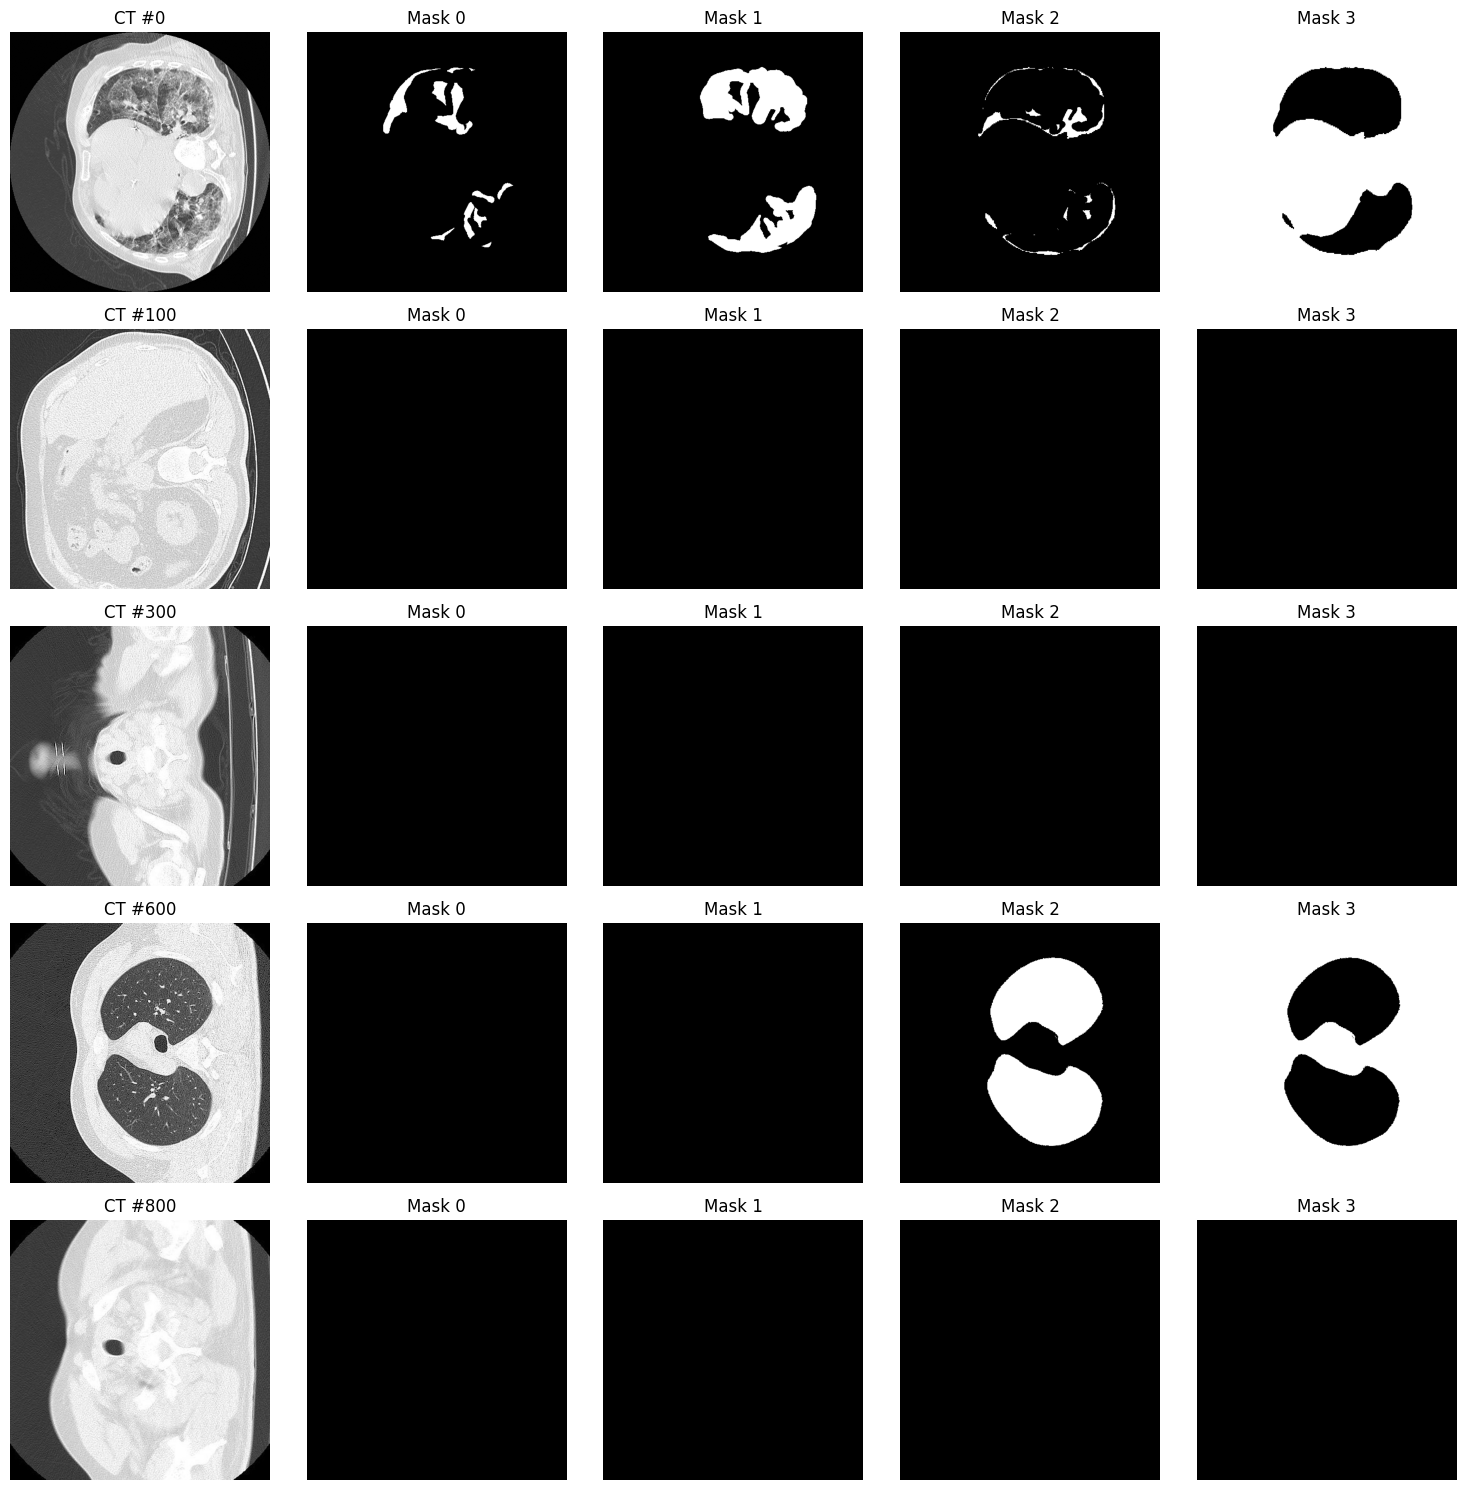

In [14]:
# ============================================================
# SHOW MULTIPLE CT SAMPLES + ALL 4 MASK CHANNELS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

indices = [0, 100, 300, 600, 800]

fig, axes = plt.subplots(
    len(indices), 5,
    figsize=(15, 3 * len(indices))
)

for row, idx in enumerate(indices):

    axes[row, 0].imshow(X[idx].squeeze(), cmap="gray")
    axes[row, 0].set_title(f"CT #{idx}")
    axes[row, 0].axis("off")

    for c in range(4):
        axes[row, c + 1].imshow(Y[idx, :, :, c], cmap="gray")
        axes[row, c + 1].set_title(f"Mask {c}")
        axes[row, c + 1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CHEST CT — GGO + CONSOLIDATION SEGMENTATION
# FAST / LIGHTWEIGHT VERSION
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

IMG_SIZE = 256
BATCH = 16
EPOCHS = 20

# ------------------------------------------------------------
# Keep only:
# Channel 0 = GGO
# Channel 1 = Consolidation
# ------------------------------------------------------------

X2 = X.astype("float32")

# Normalize CT intensity robustly
X2 = np.clip(X2, -1000, 400)
X2 = (X2 + 1000) / 1400.0

# Resize images
X2 = tf.image.resize(X2, (IMG_SIZE, IMG_SIZE)).numpy()

# Use only GGO + consolidation
Y2 = Y[..., :2].astype("float32")
Y2 = tf.image.resize(
    Y2,
    (IMG_SIZE, IMG_SIZE),
    method="nearest"
).numpy()

print("X:", X2.shape)
print("Y:", Y2.shape)

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X2, Y2,
    test_size=0.25,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, Y_train)
).shuffle(len(X_train)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, Y_val)
).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, Y_test)
).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# ------------------------------------------------------------
# Dice
# ------------------------------------------------------------

def dice_coef(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1,2]
    )

    denominator = (
        tf.reduce_sum(y_true, axis=[1,2]) +
        tf.reduce_sum(y_pred, axis=[1,2])
    )

    dice = (2.0 * intersection + smooth) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice)

# ------------------------------------------------------------
# Combined BCE + Dice loss
# ------------------------------------------------------------

def loss_fn(y_true, y_pred):

    bce = tf.reduce_mean(
        keras.losses.binary_crossentropy(
            y_true,
            y_pred
        )
    )

    dice = 1.0 - dice_coef(
        y_true,
        y_pred
    )

    return bce + dice

# ------------------------------------------------------------
# Small U-Net
# ------------------------------------------------------------

def block(x, filters):

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)

    return x


def build_model():

    inp = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    )

    # Encoder
    c1 = block(inp, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = block(p2, 64)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = block(p3, 128)

    # Decoder
    u3 = layers.UpSampling2D()(b)
    u3 = layers.Concatenate()([u3, c3])
    c4 = block(u3, 64)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = block(u2, 32)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = block(u1, 16)

    out = layers.Conv2D(
        2,
        1,
        activation="sigmoid"
    )(c6)

    return keras.Model(inp, out)


model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=loss_fn,
    metrics=[dice_coef]
)

model.summary()

I0000 00:00:1791353331.525563      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791353331.529547      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


X: (929, 256, 256, 1)
Y: (929, 256, 256, 2)
Train: (696, 256, 256, 1)
Val: (116, 256, 256, 1)
Test: (117, 256, 256, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 487,026 (1.86 MB)

 Trainable params: 487,026 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_chest_ct_model.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-10-07 06:09:25.151496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:25.431799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:26.550027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:26.849449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:27.099687: E external/local_xla/xla/stream_

 1/44 ━━━━━━━━━━━━━━━━━━━━ 15:47 22s/step - dice_coef: 0.0281 - loss: 1.6604

I0000 00:00:1791353376.113029     185 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - dice_coef: 0.0179 - loss: 1.6272

2026-10-07 06:09:44.954448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:45.237536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:46.051367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:46.354354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 06:09:46.615734: E external/local_xla/xla/stream_

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - dice_coef: 0.0178 - loss: 1.6241
Epoch 1: val_dice_coef improved from None to 0.00001, saving model to /kaggle/working/best_chest_ct_model.keras

Epoch 1: finished saving model to /kaggle/working/best_chest_ct_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 528ms/step - dice_coef: 0.0128 - loss: 1.4919 - val_dice_coef: 1.1891e-05 - val_loss: 1.1959 - learning_rate: 1.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coef: 5.0249e-04 - loss: 1.1306
Epoch 2: val_dice_coef improved from 0.00001 to 0.00271, saving model to /kaggle/working/best_chest_ct_model.keras

Epoch 2: finished saving model to /kaggle/working/best_chest_ct_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - dice_coef: 0.0010 - loss: 1.1047 - val_dice_coef: 0.0027 - val_loss: 1.0665 - learning_rate: 1.0000e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef: 0.0046 - loss: 1.0552
Epoch 3: val_dice_coef improved from 0.00271 to 0.01190, saving mo

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - dice_coef: 0.1711 - loss: 0.8520
TEST RESULTS: [0.852038562297821, 0.17113856971263885]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


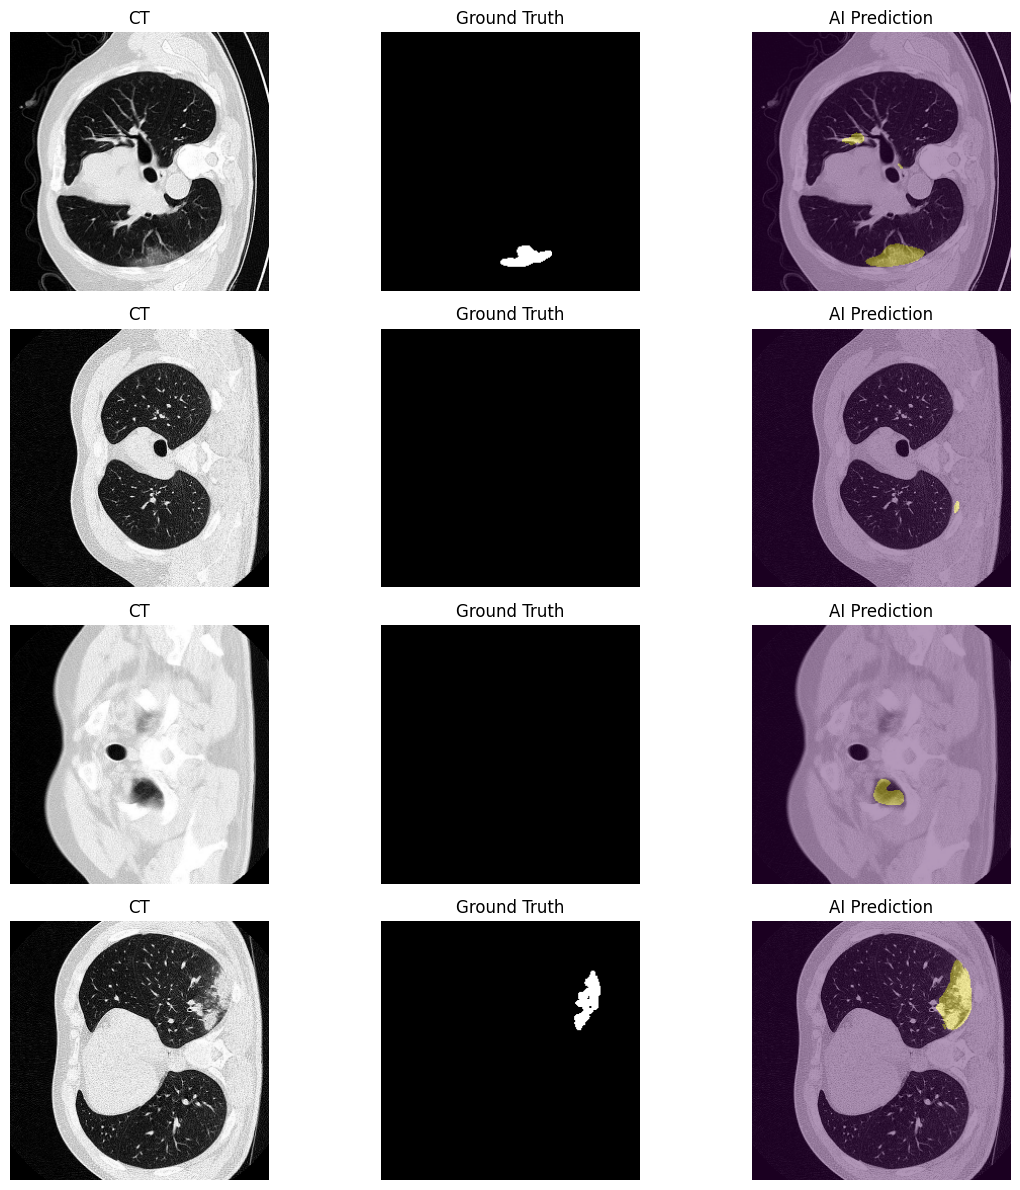

In [17]:
best_model = keras.models.load_model(
    "/kaggle/working/best_chest_ct_model.keras",
    custom_objects={
        "loss_fn": loss_fn,
        "dice_coef": dice_coef
    }
)

results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("TEST RESULTS:", results)

# Predictions
pred = best_model.predict(X_test[:4])

plt.figure(figsize=(12, 12))

for i in range(4):

    plt.subplot(4, 3, i*3+1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("CT")
    plt.axis("off")

    plt.subplot(4, 3, i*3+2)
    plt.imshow(Y_test[i].max(axis=-1), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4, 3, i*3+3)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.imshow(pred[i].max(axis=-1) > 0.5, alpha=0.4)
    plt.title("AI Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
from PIL import Image
import numpy as np

Image.fromarray(
    (X_test[0].squeeze() * 255).clip(0,255).astype(np.uint8)
).save("/kaggle/working/sample_ct.png")

In [20]:
info = """
Model: best_chest_ct_model.keras
Task: Chest CT radiological-finding segmentation

Input:
- Single 2D CT slice
- Original: 512x512
- Model input: 256x256
- 1 channel

Preprocessing:
- Clip CT values: -1000 to 400
- Normalize: (pixel + 1000) / 1400
- Resize: 256x256

Outputs:
- Channel 0: Ground-glass opacity
- Channel 1: Consolidation

Model: Lightweight 2D U-Net

Important:
This model detects/segments the radiological findings represented
in its training masks. It does NOT confirm COVID-19 or any disease.
Do not display fabricated confidence percentages.

Test Dice from Kaggle: 0.1711
"""

with open("/kaggle/working/model_info.txt", "w") as f:
    f.write(info)

print(info)


Model: best_chest_ct_model.keras
Task: Chest CT radiological-finding segmentation

Input:
- Single 2D CT slice
- Original: 512x512
- Model input: 256x256
- 1 channel

Preprocessing:
- Clip CT values: -1000 to 400
- Normalize: (pixel + 1000) / 1400
- Resize: 256x256

Outputs:
- Channel 0: Ground-glass opacity
- Channel 1: Consolidation

Model: Lightweight 2D U-Net

Important:
This model detects/segments the radiological findings represented
in its training masks. It does NOT confirm COVID-19 or any disease.
Do not display fabricated confidence percentages.

Test Dice from Kaggle: 0.1711

